# California Housing using Linear Regression

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns = data.feature_names)
df['PRICE'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
x = df.drop('PRICE', axis = 1)
y = df['PRICE']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MAE :', mae)
print('MSE :', mse)
print('RMSE :', rmse)
print('R2 Score :', r2)

MAE : 0.5332001304956553
MSE : 0.5558915986952444
RMSE : 0.7455813830127764
R2 Score : 0.5757877060324508


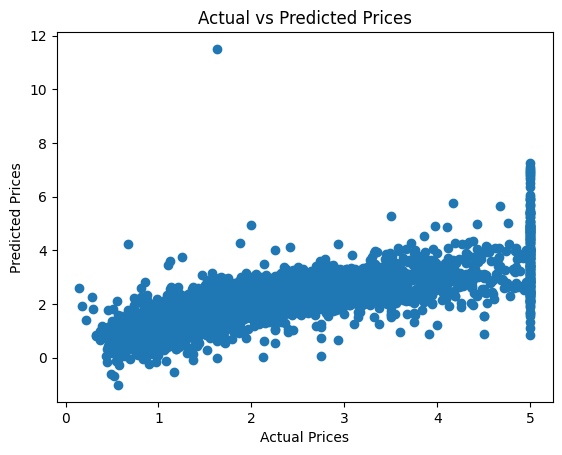

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

In [ ]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,ROOMS_PER_AGE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,0.166289
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,0.283552
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,0.156380
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,0.109761
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,0.118526
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.194056
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.321791
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.289197
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.280501


In [ ]:
x['ROOMS_PER_AGE'] = x['AveRooms'] / (x['HouseAge'] + 1)
x['POP_PER_HOUSEHOLD'] = x['Population'] / (x['AveOccup'] + 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Metrics after Feature Engineering:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Metrics after Feature Engineering:
MSE: 0.5126908197356972
R2: 0.6087551075665429


# Exercise

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
df = pd.read_csv('/content/drive/MyDrive/Salary_Data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [10]:
x = df.drop('Salary', axis = 1)
y = df['Salary']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [11]:
gbr = GradientBoostingRegressor(
n_estimators=200,
learning_rate=0.1,
max_depth=3,
random_state=42
)

gbr.fit(x_train, y_train)
y_pred = gbr.predict(x_test)

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE :', mae)
print('MSE :', mse)
print('R2 : ', r2)

MAE : 8634.158351755266
MSE : 100975895.764332
R2 :  0.8023165668545322


# Kaggle - House Price Prediction

In [28]:
df_test = pd.read_csv('/content/drive/MyDrive/ML/test.csv')
df_train = pd.read_csv('/content/drive/MyDrive/ML/train.csv')

              Missing_Count  Percentage
PoolQC                 1453   99.520548
MiscFeature            1406   96.301370
Alley                  1369   93.767123
Fence                  1179   80.753425
MasVnrType              872   59.726027
FireplaceQu             690   47.260274
LotFrontage             259   17.739726
GarageType               81    5.547945
GarageYrBlt              81    5.547945
GarageFinish             81    5.547945
GarageQual               81    5.547945
GarageCond               81    5.547945
BsmtExposure             38    2.602740
BsmtFinType2             38    2.602740
BsmtQual                 37    2.534247
BsmtCond                 37    2.534247
BsmtFinType1             37    2.534247
MasVnrArea                8    0.547945
Electrical                1    0.068493
Missing values summary:
              Missing_Count  Percentage
PoolQC                 1453   99.520548
MiscFeature            1406   96.301370
Alley                  1369   93.767123
Fence           

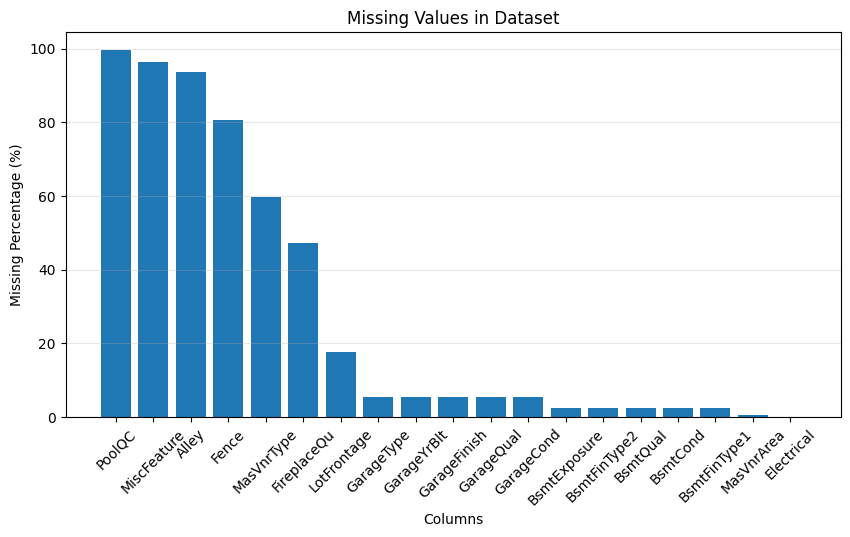

In [29]:
missing_values = df_train.isnull().sum()
missing_percent = (missing_values / len(df_train)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

print("Missing values summary:")
print(missing_df)

plt.figure(figsize=(10, 5))
plt.bar(missing_df.index, missing_df['Percentage'])
plt.xlabel('Columns')
plt.ylabel('Missing Percentage (%)')
plt.title('Missing Values in Dataset')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [30]:
df_train.drop(['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'], axis=1, inplace=True)

In [31]:
df_train['LotFrontage'].fillna(df_train['LotFrontage'].mean(), inplace=True)
df_train['MasVnrArea'].fillna((df_train['MasVnrArea']).median(), inplace=True)
modes = df_train[['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'Electrical', 'BsmtFinType1']].mode().iloc[0]
df_train[['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'Electrical', 'BsmtFinType1' ]] = df_train[['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'Electrical', 'BsmtFinType1']].fillna(modes)


/tmp/ipykernel_306/2112341476.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['LotFrontage'].fillna(df_train['LotFrontage'].mean(), inplace=True)
/tmp/ipykernel_306/2112341476.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [32]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [33]:
df_train = pd.get_dummies(df_train)

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
y = np.log1p(df_train["SalePrice"])  # Log Transformation
X = df_train.drop('SalePrice', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X.fillna(0)
model.fit(X,y).predict(X)

array([12.23527017, 12.21026897, 12.2629236 , ..., 12.55222488,
       11.86587159, 11.87917606])

In [ ]:
from sklearn.metrics import mean_absolute_error
prediction = model.predict(X_test)
error = mean_absolute_error(y_test, prediction)
print(f"Mean Absolute Error: {error:.2f}")
print(f"R-squared: {model.score(X_test, y_test):.2f}")

Mean Absolute Error: 0.07
R-squared: 0.95


In [ ]:
import pandas as pd
import numpy as np


df_test.drop(['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'],axis=1, inplace=True)

df_test['LotFrontage'].fillna(df_test['LotFrontage'].mean(), inplace=True)
df_test['MasVnrArea'].fillna(df_test['MasVnrArea'].median(), inplace=True)

cols_to_fill = ['GarageType', 'GarageYrBlt', 'GarageFinish','GarageQual', 'GarageCond', 'BsmtExposure','BsmtFinType2', 'BsmtQual', 'BsmtCond','Electrical']

df_test[cols_to_fill] = df_test[cols_to_fill].fillna(df_test[cols_to_fill].mode().iloc[0])

test_df = pd.get_dummies(df_test)

test_df = test_df.reindex(columns=X.columns, fill_value=0)

test_df = test_df.fillna(0)
predictions = model.predict(test_df)

predictions = np.expm1(predictions)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": predictions
})

submission.to_csv("submission.csv", index=False)

print("Your Submission was succesfull ")


KeyError: "['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'] not found in axis"

# XGBoost - Kaggle

In [34]:
from sklearn.model_selection import train_test_split
import numpy as np
y = np.log1p(df_train["SalePrice"])  # Log Transformation
X = df_train.drop('SalePrice', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=5,
    random_state=50
)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.5, max_depth=5, random_state=50)

In [41]:
predictions = model.predict(X_test)

In [42]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.027780107593701583
R2 Score: 0.8511335918439346


In [38]:
import pandas as pd
import numpy as np


df_test.drop(['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'],axis=1, inplace=True)

df_test['LotFrontage'].fillna(df_test['LotFrontage'].mean(), inplace=True)
df_test['MasVnrArea'].fillna(df_test['MasVnrArea'].median(), inplace=True)

cols_to_fill = ['GarageType', 'GarageYrBlt', 'GarageFinish','GarageQual', 'GarageCond', 'BsmtExposure','BsmtFinType2', 'BsmtQual', 'BsmtCond','Electrical']

df_test[cols_to_fill] = df_test[cols_to_fill].fillna(df_test[cols_to_fill].mode().iloc[0])

test_df = pd.get_dummies(df_test)

test_df = test_df.reindex(columns=X.columns, fill_value=0)

test_df = test_df.fillna(0)
predictions = model.predict(test_df)

predictions = np.expm1(predictions)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": predictions
})

submission.to_csv("submission.csv", index=False)

print("Your Submission was succesfull ")

Your Submission was succesfull 


/tmp/ipykernel_306/1183565595.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['LotFrontage'].fillna(df_test['LotFrontage'].mean(), inplace=True)
/tmp/ipykernel_306/1183565595.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val